# Scaleworm Detection Verification Lab

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook runs the YOLO "Mushroom Model" on CAMHD video frames and lets you verify each detection. Your job is to look at each cropped detection and decide: **is this a scale worm, or not?**

**Workflow:**
1. **Choose your date range** — pick which days of video to analyze
2. **Extract frames** — pull Scene 1 frames from each video (the Mushroom vent zoom)
3. **Run the detector** — YOLO finds candidate scale worms at low confidence (catches more, but includes false positives)
4. **Verify each detection** — you'll see each crop at multiple zoom levels and mark it as worm or not-worm
5. **Export** — verified true detections are packaged as a YOLO-format dataset for downstream training

</span>

## 1. Setup

In [3]:
import json
import re
import shutil
import subprocess
import zipfile
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# ── Configuration ───────────────────────────────────────────────────
# YOLO model path put mushroom.pt path here
MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
                  # "notebooks/runs/outputs/model/yolo_v26/train_v1/weights/best.pt") # in future replace with your link 

# Video archive root
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")

# Working directory for this session
WORK_DIR = Path("./verification_session")
FRAMES_DIR = WORK_DIR / "frames"
CROPS_DIR = WORK_DIR / "crops"
EXPORT_DIR = WORK_DIR / "export"

# Frame extraction parameters
SCENE1_START_SEC = 305   # Scene 1 start offset in each video
SCENE1_DURATION_SEC = 15  # Scene 1 duration
FPS = 1                  # Frames per second to extract
FRAME_W, FRAME_H = 1920, 1080

# Detection parameters
CONF_THRESHOLD = 0.1      # Low threshold to catch more candidates
MAX_BOX_SIZE = 300        # Filter out boxes larger than this (not real worms)

# Standard 3-hour cadence times (UTC)
STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

for d in [WORK_DIR, FRAMES_DIR, CROPS_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Model:     {MODEL_PATH}")
print(f"Exists:    {MODEL_PATH.exists()}")
print(f"Video root: {VIDEO_ROOT}")
print(f"Exists:    {VIDEO_ROOT.exists()}")
print(f"Work dir:  {WORK_DIR.resolve()}")
print(f"Conf threshold: {CONF_THRESHOLD}")

Model:     /home/jovyan/scaleworm-student-lab/mushroom.pt
Exists:    True
Video root: /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301
Exists:    True
Work dir:  /home/jovyan/scaleworm-student-lab/notebooks/verification_session
Conf threshold: 0.1


## 2. Choose your date range

<span style="font-family: 'Courier New', monospace;">

Run the cell below to see which dates have video available, then set your start and end dates.

</span>

In [4]:
def find_videos(video_root, start_date, end_date):
    """Find standard-cadence CAMHD videos between two dates (inclusive).

    Parameters
    ----------
    video_root : Path
        Root of the CAMHD archive (contains year/month/day subdirs).
    start_date : str
        Start date as 'YYYY-MM-DD'.
    end_date : str
        End date as 'YYYY-MM-DD'.

    Returns
    -------
    list of Path
        Sorted list of video file paths.
    """
    import datetime
    d_start = datetime.date.fromisoformat(start_date)
    d_end = datetime.date.fromisoformat(end_date)

    videos = []
    for mp4 in sorted(video_root.rglob("CAMHDA301-*.mp4")):
        m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
        if not m:
            continue
        y, mo, d, time_str = m.group(1), m.group(2), m.group(3), m.group(4)
        file_date = datetime.date(int(y), int(mo), int(d))

        if file_date < d_start or file_date > d_end:
            continue

        # Only keep standard 3-hour cadence times
        if f"T{time_str}" not in STANDARD_TIMES:
            continue

        videos.append(mp4)

    return sorted(videos)


# ════════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"   # First day to analyze (YYYY-MM-DD)
END_DATE   = "2024-10-31"   # Last day to analyze (YYYY-MM-DD)

# ════════════════════════════════════════════════════════════════════

videos = find_videos(VIDEO_ROOT, START_DATE, END_DATE)

print(f"Found {len(videos)} standard-cadence videos "
      f"between {START_DATE} and {END_DATE}:\n")
for v in videos:
    print(f"  {v.name}")

Found 247 standard-cadence videos between 2024-10-01 and 2024-10-31:

  CAMHDA301-20241001T031500.mp4
  CAMHDA301-20241001T061500.mp4
  CAMHDA301-20241001T091500.mp4
  CAMHDA301-20241001T121500.mp4
  CAMHDA301-20241001T151500.mp4
  CAMHDA301-20241001T181500.mp4
  CAMHDA301-20241001T211500.mp4
  CAMHDA301-20241002T001500.mp4
  CAMHDA301-20241002T031500.mp4
  CAMHDA301-20241002T061500.mp4
  CAMHDA301-20241002T091500.mp4
  CAMHDA301-20241002T121500.mp4
  CAMHDA301-20241002T151500.mp4
  CAMHDA301-20241002T181500.mp4
  CAMHDA301-20241002T211500.mp4
  CAMHDA301-20241003T001500.mp4
  CAMHDA301-20241003T031500.mp4
  CAMHDA301-20241003T061500.mp4
  CAMHDA301-20241003T091500.mp4
  CAMHDA301-20241003T121500.mp4
  CAMHDA301-20241003T151500.mp4
  CAMHDA301-20241003T181500.mp4
  CAMHDA301-20241003T211500.mp4
  CAMHDA301-20241004T001500.mp4
  CAMHDA301-20241004T031500.mp4
  CAMHDA301-20241004T061500.mp4
  CAMHDA301-20241004T091500.mp4
  CAMHDA301-20241004T121500.mp4
  CAMHDA301-20241004T151500.mp4
  

## 3. Extract Scene 1 frames

<span style="font-family: 'Courier New', monospace;">

Each CAMHD video is ~25 minutes long. Scene 1 (305–320 seconds) is when the camera zooms in on the Mushroom vent chimney — this is where the scale worms live. We extract frames from this 15-second window at 10 fps = 150 frames per video.

</span>

In [5]:
def extract_scene1_frames(video_path, output_dir):
    """Extract Scene 1 frames from a CAMHD video using ffmpeg.

    Returns the number of frames extracted, or 0 on failure.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    # Check if already extracted
    existing = sorted(output_dir.glob("frame_*.png"))
    if len(existing) >= FPS * SCENE1_DURATION_SEC - 1:
        return len(existing)

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(SCENE1_START_SEC),
        "-i", str(video_path),
        "-t", str(SCENE1_DURATION_SEC),
        "-vf", f"fps={FPS}",
        "-q:v", "2",
        str(output_dir / "frame_%04d.png"),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    if result.returncode != 0:
        print(f"  ERROR extracting {video_path.name}: {result.stderr[-200:]}")
        return 0

    frames = sorted(output_dir.glob("frame_*.png"))
    return len(frames)


# Extract frames for all videos
total_frames = 0
video_frame_dirs = {}  # video_name -> frame_dir

for i, vpath in enumerate(videos):
    # Use video name (without extension) as subdirectory
    vid_name = vpath.stem  # e.g., CAMHDA301-20241004T001500
    frame_dir = FRAMES_DIR / vid_name
    video_frame_dirs[vid_name] = frame_dir

    n = extract_scene1_frames(vpath, frame_dir)
    total_frames += n
    print(f"  [{i+1}/{len(videos)}] {vid_name}: {n} frames")

print(f"\nTotal: {total_frames} frames from {len(videos)} videos")

  [1/247] CAMHDA301-20241001T031500: 15 frames
  [2/247] CAMHDA301-20241001T061500: 15 frames
  [3/247] CAMHDA301-20241001T091500: 15 frames
  [4/247] CAMHDA301-20241001T121500: 15 frames
  [5/247] CAMHDA301-20241001T151500: 15 frames
  [6/247] CAMHDA301-20241001T181500: 15 frames
  [7/247] CAMHDA301-20241001T211500: 15 frames
  [8/247] CAMHDA301-20241002T001500: 15 frames
  [9/247] CAMHDA301-20241002T031500: 15 frames
  [10/247] CAMHDA301-20241002T061500: 15 frames
  [11/247] CAMHDA301-20241002T091500: 15 frames
  [12/247] CAMHDA301-20241002T121500: 15 frames
  [13/247] CAMHDA301-20241002T151500: 15 frames
  [14/247] CAMHDA301-20241002T181500: 15 frames
  [15/247] CAMHDA301-20241002T211500: 15 frames
  [16/247] CAMHDA301-20241003T001500: 15 frames
  [17/247] CAMHDA301-20241003T031500: 15 frames
  [18/247] CAMHDA301-20241003T061500: 15 frames
  [19/247] CAMHDA301-20241003T091500: 15 frames
  [20/247] CAMHDA301-20241003T121500: 15 frames
  [21/247] CAMHDA301-20241003T151500: 15 frames
 

## 4. Run the YOLO detector

<span style="font-family: 'Courier New', monospace;">

We run the Mushroom Model at a low confidence threshold (0.1) to catch as many candidates as possible. This means the model will report detections it's only 10% sure about — many will be false positives, which is exactly what you'll verify in the next step.

</span>

In [6]:
!pip install ultralytics

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.2 MB/s eta 0:00:00
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 72.0 MB/s eta 0:00:00:00:0100:01


In [7]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))
print(f"Loaded model: {MODEL_PATH.name}")

# Run inference on all extracted frames, collect detections
all_detections = []  # list of dicts with frame info + bbox

for vid_name, frame_dir in sorted(video_frame_dirs.items()):
    frames = sorted(frame_dir.glob("frame_*.png"))
    if not frames:
        continue

    results = model.predict(
        source=[str(f) for f in frames],
        conf=CONF_THRESHOLD,
        verbose=False,
        stream=True,
    )

    vid_det_count = 0
    for frame_path, result in zip(frames, results):
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        for det_idx, (box, conf) in enumerate(zip(xyxy, confs)):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1

            # Size filter: real worms are 20–100px, not 300+
            if w > MAX_BOX_SIZE or h > MAX_BOX_SIZE:
                continue

            all_detections.append({
                "video": vid_name,
                "frame_file": frame_path.name,
                "frame_path": str(frame_path),
                "det_idx": det_idx,
                "x1": float(x1), "y1": float(y1),
                "x2": float(x2), "y2": float(y2),
                "conf": float(conf),
                "label": None,  # will be set during verification
            })
            vid_det_count += 1

    print(f"  {vid_name}: {len(frames)} frames, {vid_det_count} detections")

print(f"\nTotal: {len(all_detections)} candidate detections to verify")

Loaded model: mushroom.pt
  CAMHDA301-20241001T031500: 15 frames, 0 detections
  CAMHDA301-20241001T061500: 15 frames, 1 detections
  CAMHDA301-20241001T091500: 15 frames, 28 detections
  CAMHDA301-20241001T121500: 15 frames, 0 detections
  CAMHDA301-20241001T151500: 15 frames, 13 detections
  CAMHDA301-20241001T181500: 15 frames, 61 detections
  CAMHDA301-20241001T211500: 15 frames, 136 detections
  CAMHDA301-20241002T001500: 15 frames, 0 detections
  CAMHDA301-20241002T031500: 15 frames, 13 detections
  CAMHDA301-20241002T061500: 15 frames, 9 detections
  CAMHDA301-20241002T091500: 15 frames, 5 detections
  CAMHDA301-20241002T121500: 15 frames, 0 detections
  CAMHDA301-20241002T151500: 15 frames, 0 detections
  CAMHDA301-20241002T181500: 15 frames, 0 detections
  CAMHDA301-20241002T211500: 15 frames, 25 detections
  CAMHDA301-20241003T001500: 15 frames, 14 detections
  CAMHDA301-20241003T031500: 15 frames, 0 detections
  CAMHDA301-20241003T061500: 15 frames, 6 detections
  CAMHDA301-

## 5. Crop detections

<span style="font-family: 'Courier New', monospace;">

Each detection bounding box is cropped from its source frame. The crop is padded by 20 pixels on each side so you can see context around the detection.

</span>

In [8]:
PAD_PX = 20  # Context padding around each crop

# Cache loaded frames to avoid re-reading
_frame_cache = {}

def load_frame(frame_path):
    """Load a frame image, with caching."""
    if frame_path not in _frame_cache:
        _frame_cache[frame_path] = np.array(Image.open(frame_path))
        # Keep cache manageable — drop oldest if > 50 frames
        if len(_frame_cache) > 50:
            oldest = next(iter(_frame_cache))
            del _frame_cache[oldest]
    return _frame_cache[frame_path]


def crop_detection(det, pad=PAD_PX):
    """Crop a detection from its frame with padding. Returns numpy array."""
    img = load_frame(det["frame_path"])
    h, w = img.shape[:2]

    x1 = max(0, int(det["x1"]) - pad)
    y1 = max(0, int(det["y1"]) - pad)
    x2 = min(w, int(det["x2"]) + pad)
    y2 = min(h, int(det["y2"]) + pad)

    return img[y1:y2, x1:x2]


# Pre-crop all detections and save to disk
print("Cropping detections...")
for i, det in enumerate(all_detections):
    crop = crop_detection(det)
    crop_path = CROPS_DIR / f"crop_{i:06d}.png"
    Image.fromarray(crop).save(crop_path)
    det["crop_path"] = str(crop_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(all_detections):
        print(f"  {i+1}/{len(all_detections)} crops saved")

_frame_cache.clear()  # Free memory
print("Done.")

Cropping detections...
  500/3875 crops saved
  1000/3875 crops saved
  1500/3875 crops saved
  2000/3875 crops saved
  2500/3875 crops saved
  3000/3875 crops saved
  3500/3875 crops saved
  3875/3875 crops saved
Done.


## 6. Verify detections

<span style="font-family: 'Courier New', monospace;">

Now the main event! For each candidate detection, you'll see:
- **Left panel**: The crop at its original pixel size (1×)
- **Center panel**: The crop scaled up 2× so you can see more detail
- **Right panel**: The crop scaled up 4× for fine detail inspection

Click **✓ Scale Worm** if it's a real worm, or **✗ Not a Worm** if it's a false detection (tube, bacterial mat, artifact, etc.). Click **Skip** if you're genuinely unsure — but try to make a call.

Your progress is saved after every decision, so you can stop and resume later.

</span>

In [9]:
# ── Load saved progress if resuming ─────────────────────────────────
SAVE_PATH = WORK_DIR / "verification_progress.json"

if SAVE_PATH.exists():
    with open(SAVE_PATH) as f:
        saved = json.load(f)
    # Restore labels
    for i, label in saved.get("labels", {}).items():
        idx = int(i)
        if idx < len(all_detections):
            all_detections[idx]["label"] = label
    print(f"Resumed progress: {len(saved.get('labels', {}))} detections already labeled")
else:
    print("Starting fresh — no saved progress found.")


def save_progress():
    """Save current labels to disk."""
    labels = {}
    for i, det in enumerate(all_detections):
        if det["label"] is not None:
            labels[str(i)] = det["label"]
    with open(SAVE_PATH, "w") as f:
        json.dump({"labels": labels}, f, indent=2)


# ── Verification widget ────────────────────────────────────────────
# Find first unlabeled detection
current_idx = [0]
for i, det in enumerate(all_detections):
    if det["label"] is None:
        current_idx[0] = i
        break

# Display areas
output_images = widgets.Output(layout=widgets.Layout(width="100%"))
output_info = widgets.Output(layout=widgets.Layout(width="100%"))
output_progress = widgets.Output(layout=widgets.Layout(width="100%"))

# Buttons
btn_worm = widgets.Button(
    description="✓ Scale Worm",
    button_style="success",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_not_worm = widgets.Button(
    description="✗ Not a Worm",
    button_style="danger",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_skip = widgets.Button(
    description="⟳ Skip",
    button_style="warning",
    layout=widgets.Layout(width="120px", height="50px"),
)
btn_prev = widgets.Button(
    description="◀ Previous",
    layout=widgets.Layout(width="120px", height="50px"),
)


def show_detection(idx):
    """Display the current detection at multiple resolutions."""
    det = all_detections[idx]
    crop = np.array(Image.open(det["crop_path"]))

    with output_images:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # 1× — original size
        axes[0].imshow(crop)
        axes[0].set_title("1× (original)", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        # 2× — scaled up
        crop_2x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 2, crop.shape[0] * 2), Image.NEAREST))
        axes[1].imshow(crop_2x)
        axes[1].set_title("2× zoom", fontsize=12, fontweight="bold")
        axes[1].axis("off")

        # 4× — scaled up
        crop_4x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 4, crop.shape[0] * 4), Image.NEAREST))
        axes[2].imshow(crop_4x)
        axes[2].set_title("4× zoom", fontsize=12, fontweight="bold")
        axes[2].axis("off")

        fig.tight_layout()
        plt.show()

    with output_info:
        clear_output(wait=True)
        label_str = det["label"] or "unlabeled"
        label_color = {"scale_worm": "🟢", "not_worm": "🔴", "skip": "🟡"}.get(
            det["label"], "⚪")
        print(f"Detection {idx + 1} / {len(all_detections)}  |  "
              f"Conf: {det['conf']:.3f}  |  "
              f"Video: {det['video']}  |  "
              f"Frame: {det['frame_file']}  |  "
              f"Box: [{det['x1']:.0f}, {det['y1']:.0f}, {det['x2']:.0f}, {det['y2']:.0f}]  |  "
              f"Status: {label_color} {label_str}")

    update_progress()


def update_progress():
    """Show progress bar."""
    n_done = sum(1 for d in all_detections if d["label"] is not None)
    n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
    n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
    n_skip = sum(1 for d in all_detections if d["label"] == "skip")
    n_total = len(all_detections)
    pct = 100 * n_done / max(n_total, 1)

    with output_progress:
        clear_output(wait=True)
        bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
        print(f"Progress: [{bar}] {pct:.0f}%  "
              f"({n_done}/{n_total})  |  "
              f"🟢 {n_worm} worms  |  🔴 {n_not} not-worm  |  🟡 {n_skip} skipped")


def advance():
    """Move to the next unlabeled detection."""
    start = current_idx[0]
    for offset in range(1, len(all_detections) + 1):
        candidate = (start + offset) % len(all_detections)
        if all_detections[candidate]["label"] is None:
            current_idx[0] = candidate
            show_detection(current_idx[0])
            return
    # All labeled
    current_idx[0] = len(all_detections) - 1
    show_detection(current_idx[0])
    with output_info:
        print("\n🎉  ALL DETECTIONS VERIFIED!  Proceed to Step 7 to export.")


def on_worm(b):
    all_detections[current_idx[0]]["label"] = "scale_worm"
    save_progress()
    advance()

def on_not_worm(b):
    all_detections[current_idx[0]]["label"] = "not_worm"
    save_progress()
    advance()

def on_skip(b):
    all_detections[current_idx[0]]["label"] = "skip"
    save_progress()
    advance()

def on_prev(b):
    if current_idx[0] > 0:
        current_idx[0] -= 1
    show_detection(current_idx[0])


btn_worm.on_click(on_worm)
btn_not_worm.on_click(on_not_worm)
btn_skip.on_click(on_skip)
btn_prev.on_click(on_prev)

# Layout
button_bar = widgets.HBox(
    [btn_prev, btn_worm, btn_not_worm, btn_skip],
    layout=widgets.Layout(justify_content="center", gap="10px"),
)

ui = widgets.VBox([
    output_progress,
    output_images,
    output_info,
    button_bar,
])

display(ui)
show_detection(current_idx[0])

Resumed progress: 1461 detections already labeled


## 7. Summary

<span style="font-family: 'Courier New', monospace;">

Run this cell at any time to see a summary of your verification work.

</span>

In [10]:
n_total = len(all_detections)
n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
n_skip = sum(1 for d in all_detections if d["label"] == "skip")
n_unlabeled = sum(1 for d in all_detections if d["label"] is None)

print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)
print(f"  Total detections:     {n_total:,}")
print(f"  ✓ Scale worm:         {n_worm:,} ({100*n_worm/max(n_total,1):.1f}%)")
print(f"  ✗ Not a worm:         {n_not:,} ({100*n_not/max(n_total,1):.1f}%)")
print(f"  ⟳ Skipped:            {n_skip:,}")
print(f"  ⚪ Unlabeled:          {n_unlabeled:,}")
print(f"  False positive rate:  {100*n_not/max(n_worm+n_not,1):.1f}%")
print("=" * 60)

if n_unlabeled > 0:
    print(f"\n⚠️  {n_unlabeled} detections still unlabeled. "
          "Go back to Step 6 to finish before exporting.")

VERIFICATION SUMMARY
  Total detections:     3,875
  ✓ Scale worm:         3,611 (93.2%)
  ✗ Not a worm:         88 (2.3%)
  ⟳ Skipped:            176
  ⚪ Unlabeled:          0
  False positive rate:  2.4%


## 8. Export verified detections as YOLO dataset

<span style="font-family: 'Courier New', monospace;">

This cell builds a YOLO-format dataset zip containing only the verified true detections. The zip file can be used directly for downstream YOLO training.

**YOLO format**: Each image gets a matching `.txt` label file. Each line in the label file is:
```
class_id  center_x  center_y  width  height
```
All coordinates are normalized to [0, 1] relative to the image dimensions (1920×1080).

</span>

In [12]:
def pixel_to_yolo(x1, y1, x2, y2, img_w=FRAME_W, img_h=FRAME_H):
    """Convert pixel coords (x1, y1, x2, y2) to YOLO normalized (cx, cy, w, h)."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    # Clamp to [0, 1]
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))
    return cx, cy, w, h


# Group verified worm detections by source frame
worm_dets = [d for d in all_detections if d["label"] == "scale_worm"]

if len(worm_dets) == 0:
    print("No verified worm detections to export!")
else:
    # Group by frame_path
    from collections import defaultdict
    frame_groups = defaultdict(list)
    for det in worm_dets:
        frame_groups[det["frame_path"]].append(det)

    # Build YOLO dataset directory
    img_dir = EXPORT_DIR / "images" / "train"
    lbl_dir = EXPORT_DIR / "labels" / "train"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Copy frames and write label files
    for frame_path, dets in sorted(frame_groups.items()):
        src = Path(frame_path)
        # Use video_name + frame_name for unique filenames
        video_name = dets[0]["video"]
        frame_name = dets[0]["frame_file"]
        unique_name = f"{video_name}_{frame_name}"
        stem = Path(unique_name).stem

        # Copy image
        dst_img = img_dir / unique_name
        if not dst_img.exists():
            shutil.copy2(src, dst_img)

        # Write label file
        dst_lbl = lbl_dir / f"{stem}.txt"
        with open(dst_lbl, "w") as f:
            for det in dets:
                cx, cy, w, h = pixel_to_yolo(det["x1"], det["y1"],
                                              det["x2"], det["y2"])
                f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    # Write dataset.yaml
    yaml_path = EXPORT_DIR / "dataset.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: .\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/train\n\n")  # same split — user can reorganize
        f.write(f"nc: 1\n")
        f.write(f"names:\n")
        f.write(f"  0: scale_worm\n\n")
        f.write(f"# Verified detections: {len(worm_dets)}\n")
        f.write(f"# Source frames: {len(frame_groups)}\n")
        f.write(f"# Date range: {START_DATE} to {END_DATE}\n")
        f.write(f"# Confidence threshold: {CONF_THRESHOLD}\n")
        f.write(f"# Frame size: {FRAME_W}x{FRAME_H}\n")

    # Create zip
    zip_name = f"verified_scaleworm_dataset_{START_DATE}_to_{END_DATE}.zip"
    zip_path = WORK_DIR / zip_name

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fpath in sorted(EXPORT_DIR.rglob("*")):
            if fpath.is_file():
                arcname = fpath.relative_to(EXPORT_DIR)
                zf.write(fpath, arcname)

    zip_size_mb = zip_path.stat().st_size / 1e6

    print("=" * 60)
    print("EXPORT COMPLETE")
    print("=" * 60)
    print(f"  Verified worm detections: {len(worm_dets):,}")
    print(f"  Unique frames:            {len(frame_groups):,}")
    print(f"  YOLO dataset:             {EXPORT_DIR}")
    print(f"  Zip file:                 {zip_path}")
    print(f"  Zip size:                 {zip_size_mb:.1f} MB")
    print("=" * 60)
    print(f"\nTo use this dataset for YOLO training:")
    print(f"  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920")

EXPORT COMPLETE
  Verified worm detections: 3,611
  Unique frames:            1,152
  YOLO dataset:             verification_session/export
  Zip file:                 verification_session/verified_scaleworm_dataset_2024-10-01_to_2024-10-31.zip
  Zip size:                 4519.2 MB

To use this dataset for YOLO training:
  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920


In [2]:
# Fix 1: filter to only 2024 videos for the preview
# Fix 2: better error handling so we can see what ffmpeg says

sample_videos = sorted([
    v for v in VIDEO_ROOT.rglob("CAMHDA301-*.mp4")
    if "2024" in v.name
])

if not sample_videos:
    raise FileNotFoundError("No 2024 videos found — check VIDEO_ROOT path")

PREVIEW_VIDEO = sample_videos[0]
print(f"Previewing: {PREVIEW_VIDEO.name}")
print(f"Total 2024 videos available: {len(sample_videos)}")

# Test that ffmpeg can extract a frame before launching the slider
test_path = PREVIEW_DIR / "preview_test.png"
cmd = [
    "ffmpeg", "-y",
    "-ss", str(SCENE1_START_SEC),
    "-i", str(PREVIEW_VIDEO),
    "-frames:v", "1",
    "-q:v", "2",
    str(test_path),
]
result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)

if result.returncode != 0:
    print("ffmpeg ERROR — output below:")
    print(result.stderr[-500:])
elif not test_path.exists():
    print("ffmpeg ran but no file was created — check the path:")
    print(f"  Expected: {test_path}")
else:
    print(f"Test frame extracted successfully: {test_path}")
    print("Now run the slider cell below.")

Previewing: CAMHDA301-20240101T010000.mp4
Total 2024 videos available: 8179
Test frame extracted successfully: verification_session/position_preview/preview_test.png
Now run the slider cell below.


In [4]:
all_videos = sorted(VIDEO_ROOT.rglob("CAMHDA301-*.mp4"))
print(f"Total videos found: {len(all_videos)}")
for v in all_videos[:10]:
    print(v)

Total videos found: 59419
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/09/CAMHDA301-20150709T121400Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/09/CAMHDA301-20150709T134200Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/09/CAMHDA301-20150709T155000Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/09/CAMHDA301-20150709T222700Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/10/CAMHDA301-20150710T183300Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/10/CAMHDA301-20150710T231600Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/10/CAMHDA301-20150710T233700Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/11/CAMHDA301-20150711T001100Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/11/CAMHDA301-20150711T003200Z.mp4
/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/11/CAMHDA301-20150711T010000Z.mp4


In [5]:
print(f"Preview dir: {PREVIEW_DIR}")
print(f"Exists: {PREVIEW_DIR.exists()}")

# Try writing a test file to confirm write access
test_file = PREVIEW_DIR / "write_test.txt"
test_file.write_text("test")
print(f"Write test: {'OK' if test_file.exists() else 'FAILED'}")
test_file.unlink()

Preview dir: verification_session/position_preview
Exists: True
Write test: OK


In [6]:
PREVIEW_VIDEO = all_videos[0]
out_path = PREVIEW_DIR / "manual_test.png"

cmd = [
    "ffmpeg", "-y",
    "-ss", "305",
    "-i", str(PREVIEW_VIDEO),
    "-frames:v", "1",
    "-q:v", "2",
    str(out_path),
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
print("Return code:", result.returncode)
print("STDOUT:", result.stdout[-300:])
print("STDERR:", result.stderr[-500:])
print("File exists after run:", out_path.exists())

Running: ffmpeg -y -ss 305 -i /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/2015/07/09/CAMHDA301-20150709T121400Z.mp4 -frames:v 1 -q:v 2 verification_session/position_preview/manual_test.png
Return code: 0
STDOUT: 
STDERR: ler_name    : VideoHandler
      vendor_id       : [0][0][0][0]
      encoder         : Lavc60.31.102 png
frame=    0 fps=0.0 q=0.0 size=       0kB time=N/A bitrate=N/A speed=N/A    
[out#0/image2 @ 0x55db02ad0840] video:0kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: unknown
[out#0/image2 @ 0x55db02ad0840] Output file is empty, nothing was encoded(check -ss / -t / -frames parameters if used)
frame=    0 fps=0.0 q=0.0 Lsize=N/A time=N/A bitrate=N/A speed=N/A    

File exists after run: False


In [8]:
# ── Config ───────────────────────────────────────────────────
SCENE1_START_SEC = 305
SCENE1_END_SEC   = 320
PREVIEW_DIR      = Path("./verification_session/position_preview")
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

# Filter to October 2024 videos only for preview
videos_oct_2024 = sorted([
    v for v in VIDEO_ROOT.rglob("CAMHDA301-*.mp4")
    if "202410" in v.name
])
print(f"October 2024 videos available: {len(videos_oct_2024)}")

# Dropdown to pick which video to preview
video_dropdown = widgets.Dropdown(
    options=[(v.name, v) for v in videos_oct_2024],
    description='Video:',
    layout=widgets.Layout(width='600px')
)

PREVIEW_VIDEO = videos_oct_2024[0]

slider = widgets.IntSlider(
    value=SCENE1_START_SEC,
    min=SCENE1_START_SEC,
    max=SCENE1_END_SEC,
    step=1,
    description='Offset (s):',
    continuous_update=False,
    layout=widgets.Layout(width='600px')
)
offset_label = widgets.Label(value=f"Current offset: {slider.value}s into video")
output = widgets.Output()


def extract_single_frame(video_path, offset_sec, out_path):
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(offset_sec),
        "-i", str(video_path),
        "-frames:v", "1",
        "-q:v", "2",
        str(out_path),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    return result.returncode == 0 and Path(out_path).exists()


def show_frame(video_path, offset):
    out_name  = f"{Path(video_path).stem}_offset_{offset:04d}.png"
    out_path  = PREVIEW_DIR / out_name

    if not out_path.exists():
        success = extract_single_frame(video_path, offset, out_path)
        if not success:
            with output:
                clear_output(wait=True)
                print(f"ERROR: Could not extract frame at {offset}s from {Path(video_path).name}")
            return

    with output:
        clear_output(wait=True)
        img = np.array(Image.open(out_path))
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(img)
        ax.set_title(
            f"{Path(video_path).name}  |  Offset: {offset}s",
            color='white', fontsize=10
        )
        ax.axis('off')
        fig.patch.set_facecolor('#0d1117')
        plt.tight_layout()
        plt.show()
        print(f"Video : {Path(video_path).name}")
        print(f"Offset: {offset}s  ← note this down if this looks good")


def on_slider_change(change):
    offset_label.value = f"Current offset: {change['new']}s into video"
    show_frame(video_dropdown.value, change['new'])


def on_dropdown_change(change):
    show_frame(change['new'], slider.value)


slider.observe(on_slider_change, names='value')
video_dropdown.observe(on_dropdown_change, names='value')

# Initial display
show_frame(PREVIEW_VIDEO, slider.value)

display(widgets.VBox([
    widgets.Label("1. Pick a video from the dropdown"),
    video_dropdown,
    widgets.Label("2. Scrub the slider to find the clearest worm position"),
    slider,
    offset_label,
    output
]))

October 2024 videos available: 684


In [10]:
# ============================================================
# STEP 2 — SINGLE FRAME EXTRACTOR
# Once you've identified your ideal offset above, set it here.
# This cell extracts exactly one frame per video at that offset
# across your full date range.
# ============================================================

import re
import datetime
import subprocess
import shutil
from pathlib import Path
from ultralytics import YOLO

# ── Set your chosen offset here after browsing above ─────────
FIXED_OFFSET_SEC = 320      # <-- change this to your chosen offset
START_DATE       = "2024-10-01"
END_DATE         = "2024-10-31"

SINGLE_FRAME_DIR = Path("./verification_session/single_frames")
SINGLE_FRAME_DIR.mkdir(parents=True, exist_ok=True)

STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

d_start = datetime.date.fromisoformat(START_DATE)
d_end   = datetime.date.fromisoformat(END_DATE)

# Find all videos in date range
videos = []
for mp4 in sorted(VIDEO_ROOT.rglob("CAMHDA301-*.mp4")):
    m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
    if not m:
        continue
    file_date = datetime.date(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    if file_date < d_start or file_date > d_end:
        continue
    if f"T{m.group(4)}" not in STANDARD_TIMES:
        continue
    videos.append(mp4)

print(f"Found {len(videos)} videos between {START_DATE} and {END_DATE}")
print(f"Extracting one frame per video at offset {FIXED_OFFSET_SEC}s\n")

extracted = []
failed    = []

for i, vpath in enumerate(sorted(videos)):
    out_name = f"{vpath.stem}_frame_fixed.png"
    out_path = SINGLE_FRAME_DIR / out_name

    if out_path.exists():
        print(f"  [{i+1}/{len(videos)}] Already exists — skipping: {out_name}")
        extracted.append(out_path)
        continue

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(FIXED_OFFSET_SEC),
        "-i", str(vpath),
        "-frames:v", "1",
        "-q:v", "2",
        str(out_path),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)

    if result.returncode == 0 and out_path.exists():
        print(f"  [{i+1}/{len(videos)}] ✓ {out_name}")
        extracted.append(out_path)
    else:
        print(f"  [{i+1}/{len(videos)}] ✗ FAILED: {vpath.name}")
        failed.append(vpath)

print(f"\nExtracted : {len(extracted)} frames")
print(f"Failed    : {len(failed)} frames")
print(f"Output dir: {SINGLE_FRAME_DIR}")

Found 247 videos between 2024-10-01 and 2024-10-31
Extracting one frame per video at offset 320s

  [1/247] Already exists — skipping: CAMHDA301-20241001T031500_frame_fixed.png
  [2/247] Already exists — skipping: CAMHDA301-20241001T061500_frame_fixed.png
  [3/247] Already exists — skipping: CAMHDA301-20241001T091500_frame_fixed.png
  [4/247] Already exists — skipping: CAMHDA301-20241001T121500_frame_fixed.png
  [5/247] Already exists — skipping: CAMHDA301-20241001T151500_frame_fixed.png
  [6/247] Already exists — skipping: CAMHDA301-20241001T181500_frame_fixed.png
  [7/247] Already exists — skipping: CAMHDA301-20241001T211500_frame_fixed.png
  [8/247] Already exists — skipping: CAMHDA301-20241002T001500_frame_fixed.png
  [9/247] Already exists — skipping: CAMHDA301-20241002T031500_frame_fixed.png
  [10/247] Already exists — skipping: CAMHDA301-20241002T061500_frame_fixed.png
  [11/247] Already exists — skipping: CAMHDA301-20241002T091500_frame_fixed.png
  [12/247] Already exists — ski

In [11]:
# ============================================================
# STEP 3 — RUN YOLO ON SINGLE FRAMES
# Runs the Mushroom Model on your extracted single frames and
# saves detections. No tracking needed here since each frame
# is independent — counts are directly comparable across videos.
# ============================================================

from ultralytics import YOLO
import pandas as pd
import re

MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
model      = YOLO(str(MODEL_PATH))

CONF_THRESHOLD = 0.3    # raise from 0.1 now that we have a fixed clean frame
MAX_BOX_SIZE   = 300

single_frame_detections = []

frames_to_run = sorted(SINGLE_FRAME_DIR.glob("*.png"))
print(f"Running YOLO on {len(frames_to_run)} single frames...\n")

for i, frame_path in enumerate(frames_to_run):
    # Parse video name and timestamp from filename
    m = re.search(r"CAMHDA301-(\d{8})T(\d{6})", frame_path.name)
    if not m:
        continue
    date_str = m.group(1)   # YYYYMMDD
    time_str = m.group(2)   # HHMMSS

    results = model.predict(
        source=str(frame_path),
        conf=CONF_THRESHOLD,
        verbose=False,
    )

    result     = results[0]
    boxes      = result.boxes
    det_count  = 0

    if boxes is not None and len(boxes) > 0:
        xyxy  = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        for box, conf in zip(xyxy, confs):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w > MAX_BOX_SIZE or h > MAX_BOX_SIZE:
                continue
            single_frame_detections.append({
                'frame':      frame_path.name,
                'date':       pd.to_datetime(date_str, format='%Y%m%d'),
                'time':       time_str,
                'conf':       float(conf),
                'x1': float(x1), 'y1': float(y1),
                'x2': float(x2), 'y2': float(y2),
            })
            det_count += 1

    print(f"  [{i+1}/{len(frames_to_run)}] {frame_path.name}  →  {det_count} detections")

sf_df = pd.DataFrame(single_frame_detections)
print(f"\nTotal detections across all single frames: {len(sf_df)}")
sf_df.head()

Running YOLO on 247 single frames...

  [1/247] CAMHDA301-20241001T031500_frame_fixed.png  →  0 detections
  [2/247] CAMHDA301-20241001T061500_frame_fixed.png  →  0 detections
  [3/247] CAMHDA301-20241001T091500_frame_fixed.png  →  2 detections
  [4/247] CAMHDA301-20241001T121500_frame_fixed.png  →  0 detections
  [5/247] CAMHDA301-20241001T151500_frame_fixed.png  →  0 detections
  [6/247] CAMHDA301-20241001T181500_frame_fixed.png  →  4 detections
  [7/247] CAMHDA301-20241001T211500_frame_fixed.png  →  7 detections
  [8/247] CAMHDA301-20241002T001500_frame_fixed.png  →  0 detections
  [9/247] CAMHDA301-20241002T031500_frame_fixed.png  →  1 detections
  [10/247] CAMHDA301-20241002T061500_frame_fixed.png  →  0 detections
  [11/247] CAMHDA301-20241002T091500_frame_fixed.png  →  0 detections
  [12/247] CAMHDA301-20241002T121500_frame_fixed.png  →  0 detections
  [13/247] CAMHDA301-20241002T151500_frame_fixed.png  →  0 detections
  [14/247] CAMHDA301-20241002T181500_frame_fixed.png  →  0 de

,frame,date,time,conf,x1,y1,x2,y2
0,CAMHDA301-20241001T091500_frame_fixed.png,2024-10-01,091500,0.826355,1484.932495,889.718933,1582.241455,1010.367554
1,CAMHDA301-20241001T091500_frame_fixed.png,2024-10-01,091500,0.438409,1285.307129,963.283813,1322.768311,996.832031
2,CAMHDA301-20241001T181500_frame_fixed.png,2024-10-01,181500,0.788869,470.267273,927.154175,519.236328,1012.541687
3,CAMHDA301-20241001T181500_frame_fixed.png,2024-10-01,181500,0.729678,214.073837,494.341461,271.475800,545.837097
4,CAMHDA301-20241001T181500_frame_fixed.png,2024-10-01,181500,0.552553,495.142456,209.595978,566.806152,289.375977


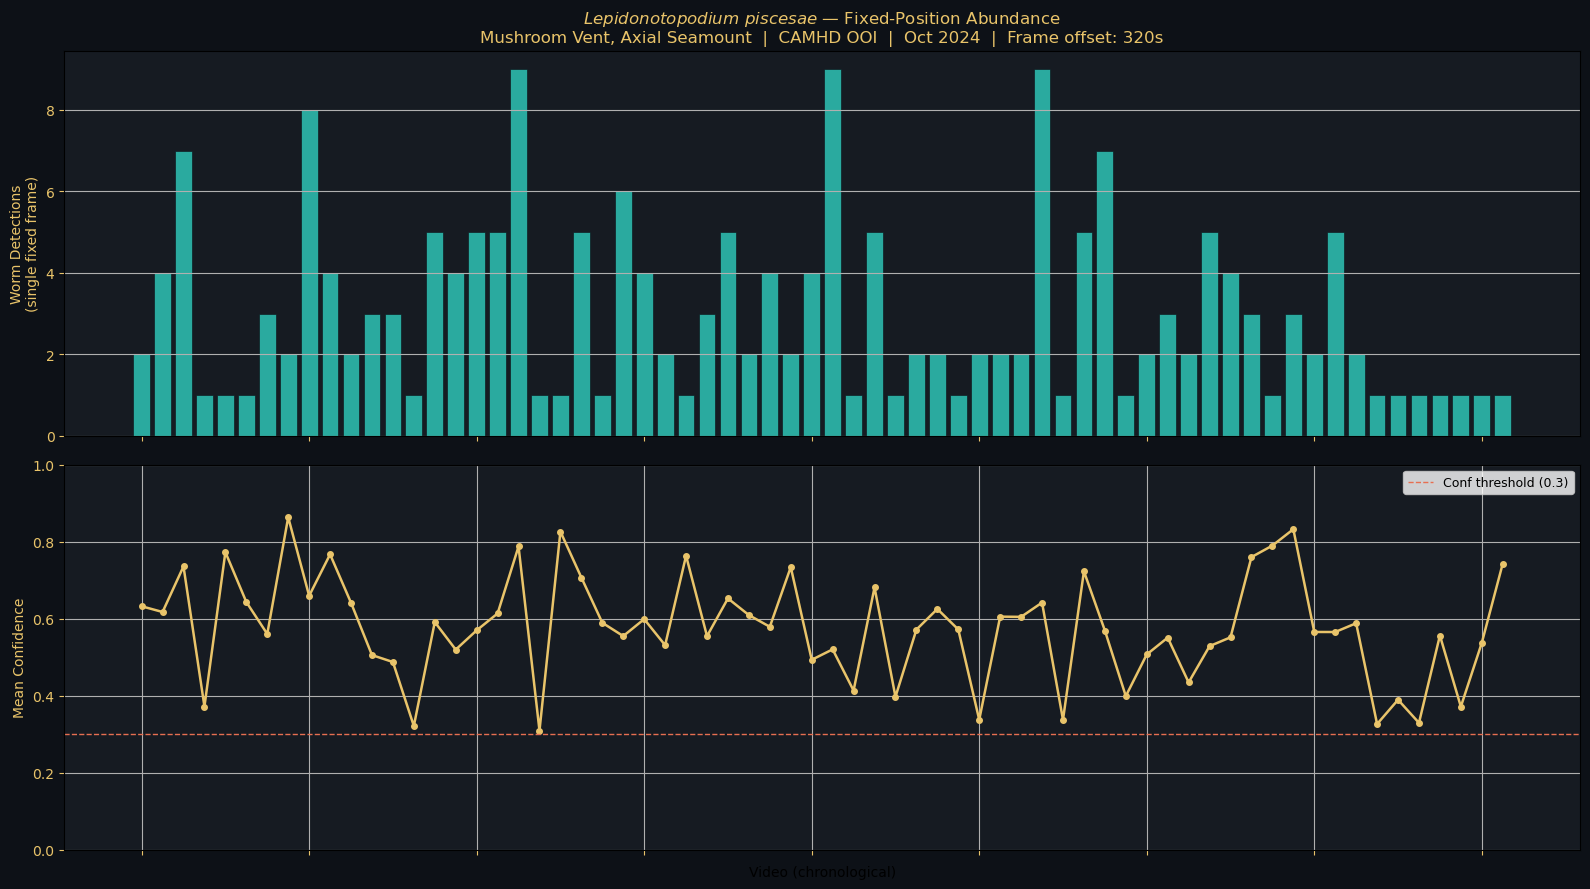

Saved: fig_single_frame_abundance.png


In [12]:
# ============================================================
# STEP 4 — PLOT SINGLE FRAME ABUNDANCE
# Each bar = one video. Height = number of worms detected in
# that one fixed frame. This is your most defensible count
# since every frame has identical field of view.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TEAL   = '#2ec4b6'
GOLD   = '#e9c46a'
ORANGE = '#e76f51'

# Aggregate — one row per video
per_video_sf = (
    sf_df.groupby(['date', 'time'])
    .agg(
        detections = ('conf', 'count'),
        mean_conf  = ('conf', 'mean'),
    )
    .reset_index()
    .sort_values('date')
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Panel 1 — detections per video as bar chart
ax = axes[0]
ax.bar(range(len(per_video_sf)), per_video_sf['detections'],
       color=TEAL, edgecolor='#0d1117', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Worm Detections\n(single fixed frame)')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Fixed-Position Abundance'
    f'\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
    f'  |  Frame offset: {FIXED_OFFSET_SEC}s',
    color='#e9c46a'
)
ax.grid(True, axis='y')
ax.yaxis.label.set_color(GOLD)
ax.tick_params(colors=GOLD)
ax.title.set_color(GOLD)

# Panel 2 — mean confidence per video
ax = axes[1]
ax.plot(range(len(per_video_sf)), per_video_sf['mean_conf'],
        color=GOLD, linewidth=1.8, marker='o', markersize=4)
ax.axhline(CONF_THRESHOLD, color=ORANGE, linewidth=1,
           linestyle='--', label=f'Conf threshold ({CONF_THRESHOLD})')
ax.set_ylabel('Mean Confidence')
ax.set_xlabel('Video (chronological)')
ax.set_ylim(0, 1)
ax.legend(fontsize=9, labelcolor='black')
ax.grid(True)
ax.yaxis.label.set_color(GOLD)
ax.tick_params(colors=GOLD)

# X tick labels — show date every 8 videos (roughly every day)
tick_positions = range(0, len(per_video_sf), 8)
tick_labels    = [
    per_video_sf.iloc[i]['date'].strftime('%b %d')
    for i in tick_positions
]
for a in axes:
    a.set_xticks(list(tick_positions))
axes[1].set_xticklabels(tick_labels, rotation=35, ha='right', color=GOLD)
axes[0].set_xticklabels([], color=GOLD)

fig.patch.set_facecolor('#0d1117')
for a in axes:
    a.set_facecolor('#161b22')

fig.tight_layout()
plt.savefig(
    Path("./verification_session/export") / 'fig_single_frame_abundance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: fig_single_frame_abundance.png")

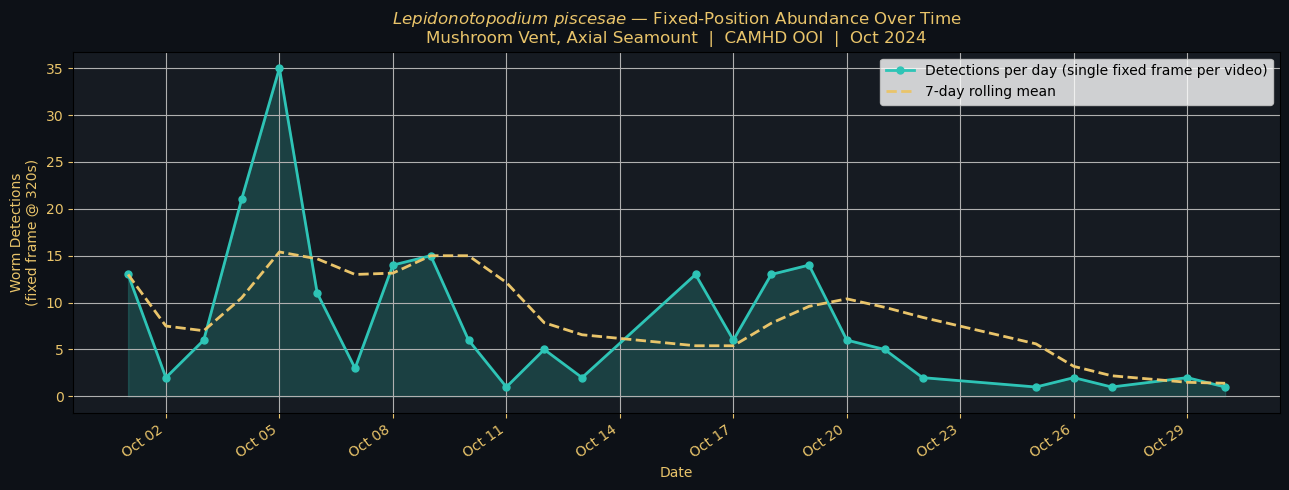

Saved: fig_fixed_frame_daily.png


In [15]:
# ============================================================
# Single frame detections over time
# Same style as the estimated individual abundance chart
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
EXPORT_DIR = Path('./verification_session/export')
TEAL   = '#2ec4b6'
GOLD   = '#e9c46a'
ORANGE = '#e76f51'

# Aggregate by date (sum detections across all videos that day)
daily_sf = (
    per_video_sf.groupby('date')
    .agg(
        total_detections = ('detections', 'sum'),
        mean_conf        = ('mean_conf',  'mean'),
        videos_that_day  = ('detections', 'count'),
    )
    .reset_index()
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(daily_sf['date'], daily_sf['total_detections'],
                alpha=0.22, color=TEAL)
ax.plot(daily_sf['date'], daily_sf['total_detections'],
        color=TEAL, linewidth=2, marker='o', markersize=5,
        label='Detections per day (single fixed frame per video)')

# 7-day rolling mean
if len(daily_sf) >= 7:
    rolling = daily_sf.set_index('date')['total_detections'].rolling('7D').mean()
    ax.plot(rolling.index, rolling.values,
            color=GOLD, linewidth=2, linestyle='--', label='7-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right', color=GOLD)
ax.set_xlabel('Date', color=GOLD)
ax.set_ylabel('Worm Detections\n(fixed frame @ 320s)', color=GOLD)
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Fixed-Position Abundance Over Time'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024',
    color=GOLD
)
ax.tick_params(colors=GOLD)
ax.legend(facecolor='white', labelcolor='black')
ax.grid(True)
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig_fixed_frame_daily.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_fixed_frame_daily.png')

In [17]:
# Rebuild original daily detections from label files
import re
import pandas as pd
from pathlib import Path
from datetime import datetime

LABELS_DIR = Path('./verification_session/export/labels/train')
FNAME_REGEX = re.compile(r'(\d{8})T(\d{6})_frame_(\d+)')

records = []
for txt in sorted(LABELS_DIR.glob('*.txt')):
    m = FNAME_REGEX.search(txt.stem)
    if not m:
        continue
    try:
        dt = datetime.strptime(f'{m.group(1)}{m.group(2)}', '%Y%m%d%H%M%S')
    except ValueError:
        continue

    with open(txt, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            records.append({
                'date': dt.date(),
                'filename': txt.stem,
            })

orig_df = pd.DataFrame(records)
daily = (
    orig_df.groupby('date')
    .agg(detections=('filename', 'count'))
    .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])

print(f'Rebuilt original daily detections: {len(daily)} days, {daily["detections"].sum()} total')
print(daily.to_string(index=False))

Rebuilt original daily detections: 31 days, 2438 total
      date  detections
2024-10-01         209
2024-10-02          41
2024-10-03          91
2024-10-04         200
2024-10-05         310
2024-10-06         111
2024-10-07          57
2024-10-08         162
2024-10-09         112
2024-10-10          87
2024-10-11          40
2024-10-12          72
2024-10-13          42
2024-10-14           6
2024-10-15          13
2024-10-16         159
2024-10-17          78
2024-10-18         123
2024-10-19         121
2024-10-20         104
2024-10-21          56
2024-10-22          29
2024-10-23          39
2024-10-24          17
2024-10-25           8
2024-10-26          28
2024-10-27          23
2024-10-28          18
2024-10-29          47
2024-10-30          27
2024-10-31           8


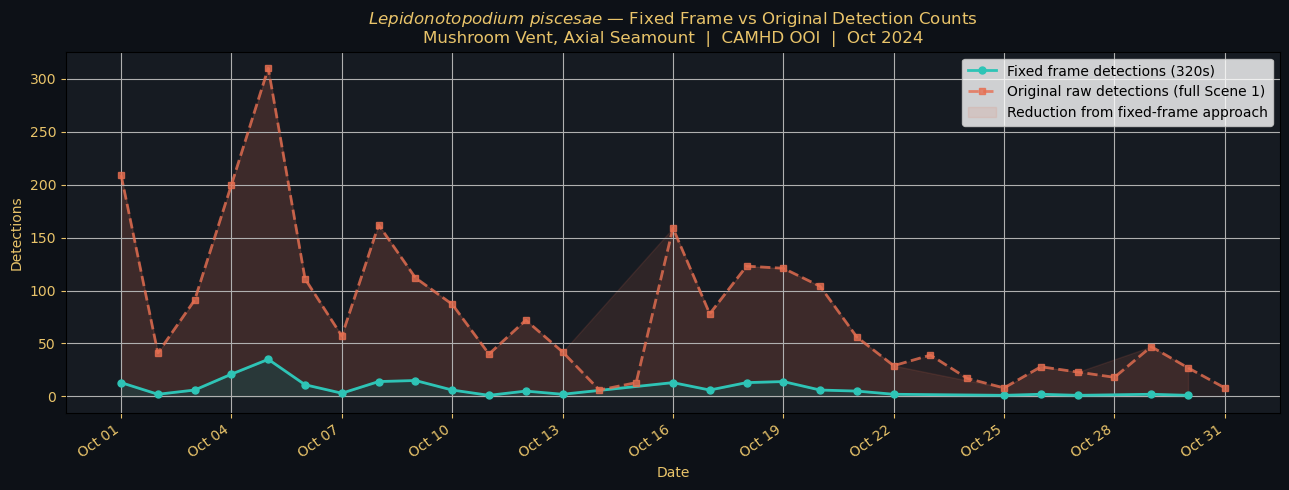

Saved: fig_fixed_vs_original.png


In [18]:
# ============================================================
# Fixed frame detections vs original raw detections comparison
# Shows how much the single-frame approach reduces inflation
# ============================================================

# Pull daily totals from your original analysis for comparison
# (requires daily DataFrame from the analysis notebook —
#  if not available, load from the export dir label files)
try:
    # If daily is already in memory from the analysis notebook
    daily_original = daily.copy()
    daily_original['date'] = pd.to_datetime(daily_original['date'])
    has_original = True
except NameError:
    has_original = False
    print("Note: original daily detections not in memory — showing fixed frame only")

fig, ax = plt.subplots(figsize=(13, 5))

# Fixed frame detections
ax.plot(daily_sf['date'], daily_sf['total_detections'],
        color=TEAL, linewidth=2, marker='o', markersize=5,
        label='Fixed frame detections (320s)')
ax.fill_between(daily_sf['date'], daily_sf['total_detections'],
                alpha=0.15, color=TEAL)

if has_original:
    # Original raw detections from full Scene 1 window
    ax.plot(daily_original['date'], daily_original['detections'],
            color=ORANGE, linewidth=2, marker='s', markersize=4,
            linestyle='--', label='Original raw detections (full Scene 1)',
            alpha=0.8)
    ax.fill_between(daily_original['date'], daily_original['detections'],
                    alpha=0.08, color=ORANGE)

    # Shade the inflation gap
    merged = pd.merge(daily_sf, daily_original,
                      on='date', suffixes=('_sf', '_orig'), how='inner')
    ax.fill_between(merged['date'],
                    merged['total_detections'],
                    merged['detections'],
                    alpha=0.12, color=ORANGE,
                    label='Reduction from fixed-frame approach')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right', color=GOLD)
ax.set_xlabel('Date', color=GOLD)
ax.set_ylabel('Detections', color=GOLD)
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Fixed Frame vs Original Detection Counts'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024',
    color=GOLD
)
ax.tick_params(colors=GOLD)
ax.legend(facecolor='white', labelcolor='black')
ax.grid(True)
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig_fixed_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_fixed_vs_original.png')

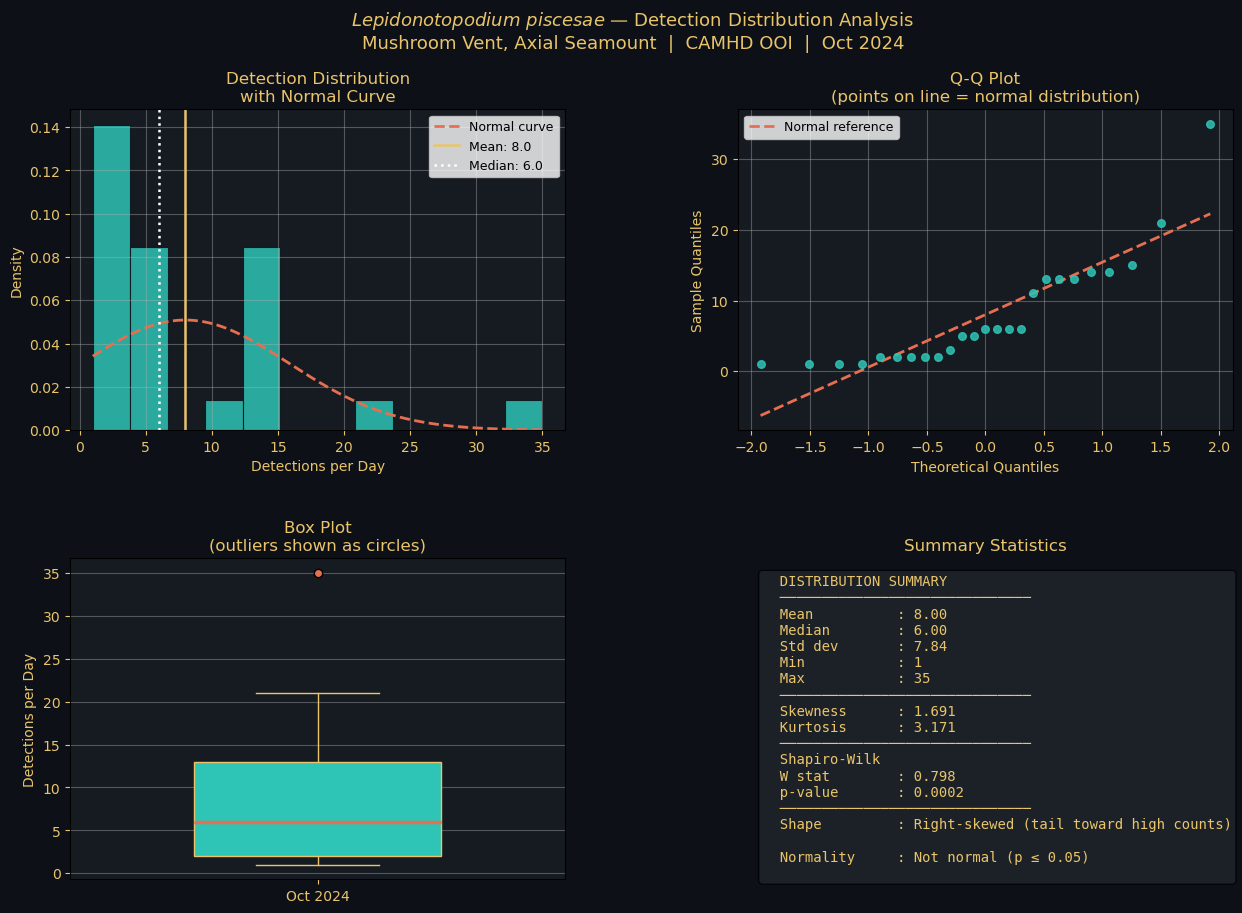

Saved: fig_distribution.png


In [19]:
# ============================================================
# Distribution charts — fixed frame detections
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats

TEAL   = '#2ec4b6'
GOLD   = '#e9c46a'
ORANGE = '#e76f51'

det_values = daily_sf['total_detections'].values

# Normality test
stat, p_value = stats.shapiro(det_values)
is_normal = p_value > 0.05

fig = plt.figure(figsize=(15, 10))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Histogram with normal curve overlay ─────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#161b22')
n, bins, patches = ax1.hist(det_values, bins=12,
                             color=TEAL, edgecolor='#0d1117',
                             linewidth=0.8, density=True, alpha=0.85)
# Overlay normal curve
mu, sigma = det_values.mean(), det_values.std()
x = np.linspace(det_values.min(), det_values.max(), 200)
ax1.plot(x, stats.norm.pdf(x, mu, sigma),
         color=ORANGE, linewidth=2, linestyle='--', label='Normal curve')
ax1.axvline(mu, color=GOLD, linewidth=1.8,
            linestyle='-', label=f'Mean: {mu:.1f}')
ax1.axvline(np.median(det_values), color='white', linewidth=1.8,
            linestyle=':', label=f'Median: {np.median(det_values):.1f}')
ax1.set_xlabel('Detections per Day', color=GOLD)
ax1.set_ylabel('Density', color=GOLD)
ax1.set_title('Detection Distribution\nwith Normal Curve', color=GOLD)
ax1.tick_params(colors=GOLD)
ax1.legend(facecolor='white', labelcolor='black', fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2: Q-Q plot ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#161b22')
(osm, osr), (slope, intercept, r) = stats.probplot(det_values, dist='norm')
ax2.scatter(osm, osr, color=TEAL, s=30, zorder=3, alpha=0.85)
ax2.plot(osm, slope * np.array(osm) + intercept,
         color=ORANGE, linewidth=2, linestyle='--', label='Normal reference')
ax2.set_xlabel('Theoretical Quantiles', color=GOLD)
ax2.set_ylabel('Sample Quantiles', color=GOLD)
ax2.set_title('Q-Q Plot\n(points on line = normal distribution)', color=GOLD)
ax2.tick_params(colors=GOLD)
ax2.legend(facecolor='white', labelcolor='black', fontsize=9)
ax2.grid(True, alpha=0.4)

# ── Panel 3: Box plot ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#161b22')
bp = ax3.boxplot(det_values, patch_artist=True, vert=True,
                 widths=0.5,
                 boxprops=dict(facecolor=TEAL, color=GOLD),
                 medianprops=dict(color=ORANGE, linewidth=2.5),
                 whiskerprops=dict(color=GOLD),
                 capprops=dict(color=GOLD),
                 flierprops=dict(marker='o', color=GOLD,
                                 markerfacecolor=ORANGE, markersize=6))
ax3.set_ylabel('Detections per Day', color=GOLD)
ax3.set_title('Box Plot\n(outliers shown as circles)', color=GOLD)
ax3.tick_params(colors=GOLD)
ax3.set_xticklabels(['Oct 2024'], color=GOLD)
ax3.grid(True, axis='y', alpha=0.4)

# ── Panel 4: Summary stats + normality test ───────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#161b22')
ax4.axis('off')

skewness = stats.skew(det_values)
kurtosis = stats.kurtosis(det_values)

if skewness > 0.5:
    skew_interp = 'Right-skewed (tail toward high counts)'
elif skewness < -0.5:
    skew_interp = 'Left-skewed (tail toward low counts)'
else:
    skew_interp = 'Approximately symmetric'

if is_normal:
    normality_interp = 'Likely normal (p > 0.05)'
else:
    normality_interp = 'Not normal (p ≤ 0.05)'

stats_text = (
    f"  DISTRIBUTION SUMMARY\n"
    f"  {'─'*30}\n"
    f"  Mean          : {mu:.2f}\n"
    f"  Median        : {np.median(det_values):.2f}\n"
    f"  Std dev       : {sigma:.2f}\n"
    f"  Min           : {det_values.min()}\n"
    f"  Max           : {det_values.max()}\n"
    f"  {'─'*30}\n"
    f"  Skewness      : {skewness:.3f}\n"
    f"  Kurtosis      : {kurtosis:.3f}\n"
    f"  {'─'*30}\n"
    f"  Shapiro-Wilk\n"
    f"  W stat        : {stat:.3f}\n"
    f"  p-value       : {p_value:.4f}\n"
    f"  {'─'*30}\n"
    f"  Shape         : {skew_interp}\n\n"
    f"  Normality     : {normality_interp}\n"
)

ax4.text(0.05, 0.95, stats_text,
         transform=ax4.transAxes,
         fontsize=10, verticalalignment='top',
         fontfamily='monospace', color=GOLD,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))
ax4.set_title('Summary Statistics', color=GOLD)

fig.suptitle(
    r'$Lepidonotopodium\ piscesae$ — Detection Distribution Analysis'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024',
    color=GOLD, fontsize=13
)

plt.savefig(EXPORT_DIR / 'fig_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_distribution.png')